# Analysis for Lắc Bầu Cua (Vietnamese Lunar New Year game)

Can the right betting strategy survive all 10 rounds and walk away with profit after a session?

### Strategy 

**All In**: Bets the entire $12 bankroll each round spreading across 1-6 symbols ( ex. $12 for 1 bet).

**Conservative**: Bets half the $12 bankroll evenly spreading across 1-6 symbols (ex. $6 for 1 bet conserves $6).

Numbers at the end of each strategy represent how many symbols the bet is split across.


In [286]:
import glob
import pandas as pd
from math import comb
import matplotlib.pyplot as plt

In [287]:
files = sorted(glob.glob("StrategyCSVs_10/*.csv"))
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
df.head()

,Session,Strategy_Name,Starting_Bankroll,Max_Rounds,Cost_Per_Round,Rounds_Survived,Final_Bankroll,Bet_Sheet
0,1,1BetAllInAt12Dollars,12.0,10,12.0,10,12.0,FISH:12.0
1,2,1BetAllInAt12Dollars,12.0,10,12.0,10,108.0,FISH:12.0
2,3,1BetAllInAt12Dollars,12.0,10,12.0,6,0.0,FISH:12.0
3,4,1BetAllInAt12Dollars,12.0,10,12.0,1,0.0,FISH:12.0
4,5,1BetAllInAt12Dollars,12.0,10,12.0,1,0.0,FISH:12.0


Clean up strategy labels for consistency

In [288]:
name_map = {
    "1BetAllInAt12Dollars": "All_In_1Bet",
    "2BetAllInAt12Dollars": "All_In_2Bet",
    "3BetAllInAt12Dollars": "All_In_3Bet",
    "4BetAllInAt12Dollars": "All_In_4Bet",
    "5BetAllInAt12Dollars": "All_In_5Bet",
    "6AllInAt12Dollars": "All_In_6Bet",
    "Conserve6": "Conservative_6Bet",
    "ConserveBet1": "Conservative_1Bet",
    "ConserveBet2": "Conservative_2Bet",
    "ConserveBet3": "Conservative_3Bet",
    "ConserveBet4": "Conservative_4Bet",
    "ConserveBet5": "Conservative_5Bet",
}

df["Strategy_Name"] = df["Strategy_Name"].map(name_map)

## Strategy Performance Summary

Survival rates, average rounds survived, and profit distributions across all strategies.

In [289]:
df["Success"] = df["Rounds_Survived"] == df["Max_Rounds"]
df["Profit"] = df["Final_Bankroll"] - df["Starting_Bankroll"]

summary = df.groupby("Strategy_Name").agg(
    Success_Rate=("Success", "mean"),
    Avg_Rounds=("Rounds_Survived", "mean"),
    Median_Profit=("Profit", "median"),
    Return_Pct=("Profit", "mean"),
    Profit_SD=("Profit", "std")
)

summary["Success_Rate"] = (summary["Success_Rate"] * 100).round(1)
summary["Avg_Rounds"] = summary["Avg_Rounds"].round(1)
summary["Median_Profit"] = summary["Median_Profit"].round(2)
summary["Return_Pct"] = (summary["Return_Pct"] / 12 * 100).round(2)
summary["Profit_SD"] = summary["Profit_SD"].round(2)

display(summary.reset_index())

,Strategy_Name,Success_Rate,Avg_Rounds,Median_Profit,Return_Pct,Profit_SD
0,All_In_1Bet,17.9,3.5,-12.0,-28.90,21.86
1,All_In_2Bet,17.6,4.1,-12.0,-45.45,13.72
2,All_In_3Bet,13.0,3.2,-4.0,-28.00,9.20
3,All_In_4Bet,14.7,3.8,-6.0,-28.98,5.96
4,All_In_5Bet,9.8,3.1,-2.4,-24.88,3.17
5,All_In_6Bet,0.2,2.2,-2.0,-17.62,0.47
6,Conservative_1Bet,38.9,6.1,-12.0,-21.65,14.86
7,Conservative_2Bet,46.6,7.2,-9.0,-27.72,10.50
8,Conservative_3Bet,47.8,7.3,-8.0,-30.85,7.28
9,Conservative_4Bet,55.8,8.0,-6.0,-32.20,5.53


## Game Probability

Probability of matching dice and the expected value per bet.

In [290]:
total = 6**3 

probs = []
for matches in range(4):
    binomial_prob = comb(3, matches) * (1/6)**matches * (5/6)**(3-matches)
    probs.append(round(binomial_prob, 4))

ev_df = pd.DataFrame({
    "Matches": [0, 1, 2, 3],
    "Multiplier": [-1, 1, 2, 3],
    "Probability": probs
})

ev_df["Multiplier x Probability"] = ev_df["Multiplier"] * ev_df["Probability"]

display(ev_df)
print(f"\nTotal EV: {ev_df['Multiplier x Probability'].sum() * 100:.2f}%")

,Matches,Multiplier,Probability,Multiplier x Probability
0,0,-1,0.5787,-0.5787
1,1,1,0.3472,0.3472
2,2,2,0.0694,0.1388
3,3,3,0.0046,0.0138



Total EV: -7.89%


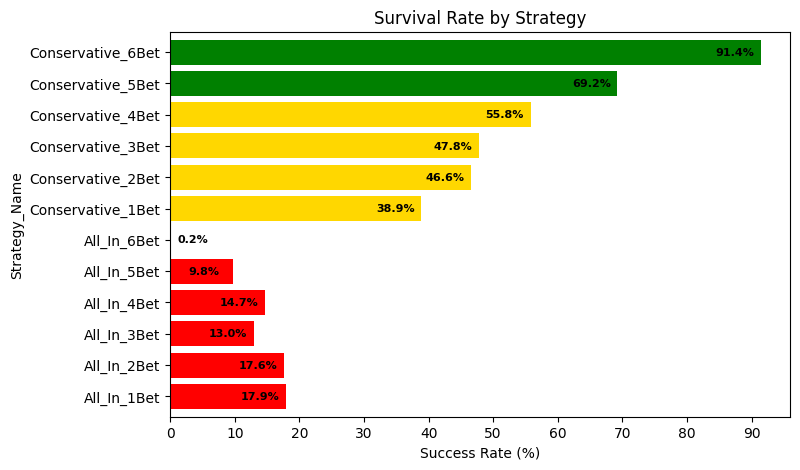

In [295]:
summary_sorted = summary.sort_values("Strategy_Name")

colors = ["green" if x > 60 else "gold" if x > 20 else "red" for x in summary_sorted["Success_Rate"]]

summary_sorted.plot.barh(
    y="Success_Rate",
    legend=False,
    figsize=(8, 5),
    color=colors,
    width = .8
)
plt.xlabel("Success Rate (%)")
plt.title("Survival Rate by Strategy")
for pos, rate in enumerate(summary_sorted["Success_Rate"]):
    offset = 1 if rate < 1 else -7
    plt.text(rate + offset, pos, f"{rate}%", va="center", fontsize=8, fontweight="bold")
plt.xticks(range(0, 100, 10))
plt.show()

Conservative strategies are a clear winner to last longer in a session, while All In strategies struggle for survival. 

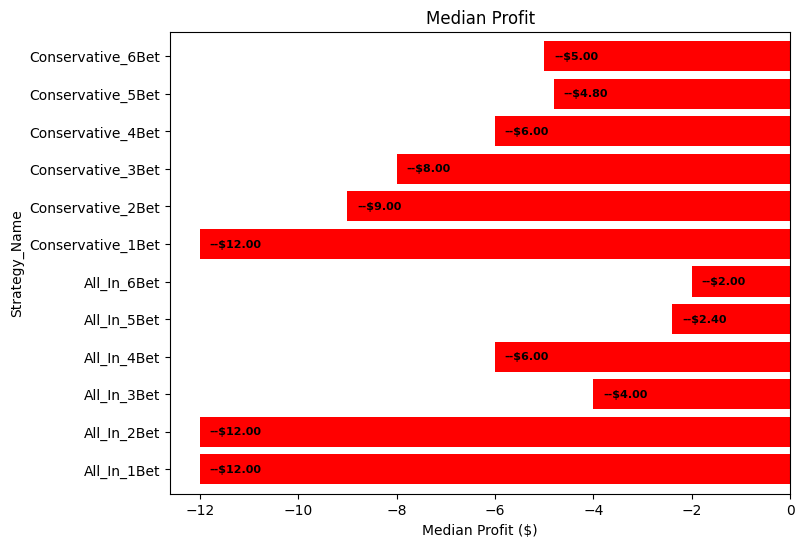

In [292]:
summary_sorted.plot.barh(
    y="Median_Profit", 
    legend=False, 
    figsize=(8, 6),
    color = "red",
    width = .8
)
plt.xlabel("Median Profit ($)")
plt.title("Median Profit")
for pos, profit in enumerate(summary_sorted["Median_Profit"]):
    plt.text(profit+ .2, pos, f"--${abs(profit):.2f}", va="center", fontsize=8, fontweight = "bold")

plt.xticks(range(0, -14, -2))
plt.show()

No matter the strategy, it's clearly impossible to win against the house long term. Interestingly, a safe bet like Conservative 1 Bet still loses the same$-12.00 as a strategy as aggressive as going All In with 1 or 2 bets. 

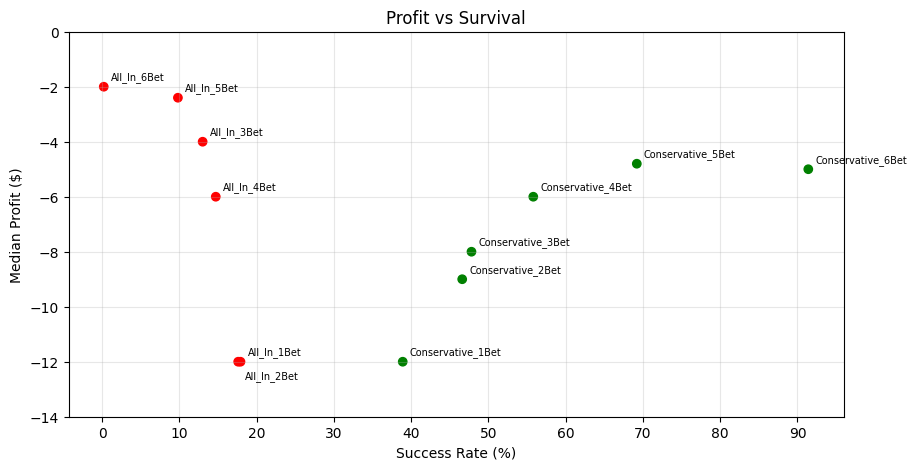

In [293]:
plt.figure(figsize=(10, 5))
colors = ["red" if "All_In" in name else "green" for name in summary_sorted.index]
plt.scatter(summary_sorted["Success_Rate"], summary_sorted["Median_Profit"], c = colors)

for pos, name in enumerate(summary_sorted.index):
    x = summary_sorted["Success_Rate"].iloc[pos]
    y = summary_sorted["Median_Profit"].iloc[pos]
    
    if name == "All_In_2Bet":
        plt.annotate(name, (x, y), fontsize=7, textcoords="offset points", xytext=(5, -12))
    else:    
        plt.annotate(name, (x, y), fontsize=7, textcoords="offset points", xytext=(5, 5))
                
plt.grid(True, alpha=0.3)
plt.xlabel("Success Rate (%)")
plt.ylabel("Median Profit ($)")
plt.title("Profit vs Survival")
plt.xticks(range(0, 100, 10))
plt.yticks(range(0, -16, -2))
plt.show()

The longer you're alive in the game doesn't mean you'll lose less. Here it shows a clear trade off of survival for profit. 

In [294]:
max_profit = df.groupby("Strategy_Name")["Profit"].max()
profit_exist = df[df["Profit"] > 0].groupby("Strategy_Name").size()
total_profit = df.groupby("Strategy_Name").size()
profit_pct = round(profit_exist/total_profit * 100, 1)

result = pd.DataFrame({
    "max_profit" : max_profit,
    "profit_pct": profit_pct
    
})

print(result.reset_index().to_string(index=False))

    Strategy_Name  max_profit  profit_pct
      All_In_1Bet       144.0        14.9
      All_In_2Bet        60.0        14.4
      All_In_3Bet        56.0        11.1
      All_In_4Bet        30.0        10.9
      All_In_5Bet        21.6         6.5
      All_In_6Bet         0.0         NaN
Conservative_1Bet        78.0        28.6
Conservative_2Bet        36.0        29.4
Conservative_3Bet        28.0        24.3
Conservative_4Bet        18.0        21.7
Conservative_5Bet         6.0        12.3
Conservative_6Bet         0.0         NaN


## Key Findings

- All in 1 or 2 bets are similar where it dies out early and share -$12 median profit, but differs in their return percentages -28.90% and -45.45%, so splitting bets means less returned per win.
- A good middle ground would be either conservative bet 2 or 3 to balance survival with lower median losses
- Conservative 6 Bet survives 91.4% of the time but has the worst return at -38.95%, showing the tradeoff between survival and profit.
- No strategies profited more than 29.4% of the time, while both Conservative and All In 6 bet strategies never profited at all.

### Conclusion

To answer the question of can the right betting strategy survive all 10 rounds and walk away with profit after a session? This analysis has evidence to reason there is **no strategy to walk away successfully with profit in a 10 round game.** Every strategy ends with a negative profit distribution and the house edges -7.89% per dollar bet makes it near impossible for any method to win long term. Winning with profit exists but it's rare since no strategy wins above 30 percent of a 1000 run 10 round game.

As bets are spread across more symbols, variance or volatility drops and survival improves, but return percentage worsens. Overall Conservative strategies survive the longest but slowly lose money over time. All in strategies lose less money but are more likely to bust before reaching 10 rounds, averaging 2-4 rounds survived. Leading back to the tradeoff of profit for survival. It’s safe to expect not to walk with any profit in a typical game session.